<a href="https://colab.research.google.com/github/lfmuneramm/Aprendizaje_No_Supervisado/blob/main/Parcial_LFM_An%C3%A1litica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Caso de Estudio**

Una entidad del sector salud en Colombia desea identificar los factores que tienen un mayor impacto sobre la probabilidad de que una persona sufra un ataque cardiaco. Para ello, se cuenta con una base de datos que incluye variables clínicas y de estilo de vida tales como: Age, Cholesterol, Heart Rate, Exercise Hour, Income, BMI, Triglycerides y Sleep Hours per Day, además de la variable objetivo Heart Attack, que indica si el paciente ha sufrido o no un evento cardiaco.

El objetivo del estudio es doble: por un lado, obtener un entendimiento claro de cuáles son las variables más influyentes en el riesgo de ataque cardiaco, y por otro, implementar modelos predictivos y de agrupamiento que permitan apoyar la toma de decisiones en la prevención de enfermedades cardiovasculares.

Para cumplir con estos objetivos, se llevarán a cabo los siguientes procedimientos:

Selección de variables relevantes: identificar las cinco variables numéricas con mayor correlación con la variable de ataque cardiaco.

Modelos de clasificación: entrenar y comparar un modelo de Naive Bayes y un Árbol de Decisión, con el fin de evaluar cuál ofrece un mejor desempeño en la predicción del riesgo.

Extracción de reglas de negocio: a partir del árbol de decisión, interpretar los nodos puros y derivar reglas claras que orienten a la entidad en la gestión del riesgo cardiovascular.

Clusterización con K-Means: realizar un agrupamiento en cinco clusters para caracterizar a la población, identificar grupos de mayor vulnerabilidad y analizar las proporciones de pacientes con riesgo de ataque cardiaco en cada segmento.

Análisis de resultados: responder preguntas clave relacionadas con las variables más influyentes, el número de personas afectadas, el mejor modelo de predicción, las reglas derivadas del árbol y la caracterización de los clusters obtenidos.

Este enfoque integral permite a la entidad no solo predecir casos de riesgo, sino también comprender los patrones subyacentes y diseñar estrategias preventivas basadas en evidencia.

0. Importamos las librerias necesarias

In [24]:
# Paso 1: Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
from pydotplus import graph_from_dot_data
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

1. Cargamos la base de datos y visualizamos información sobre ella.

In [25]:
# Reemplaza con el nombre exacto de tu archivo CSV
nxl = "/content/3. heart_attack_pronostico_int.xlsx"

XDB=pd.read_excel(nxl, sheet_name=0)


#Seleccionamos las columnas y las visualizamos
XDB.columns


#Miramos información de los datos y miramos si hay datos nulos
XDB.info()

XDB.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient ID                       8763 non-null   object 
 1   Age                              8763 non-null   int64  
 2   Sex                              8763 non-null   object 
 3   Cholesterol                      8763 non-null   int64  
 4   Blood Pressure                   8763 non-null   object 
 5   Heart Rate                       8763 non-null   int64  
 6   Diabetes                         8763 non-null   int64  
 7   Family History                   8763 non-null   int64  
 8   Smoking                          8763 non-null   int64  
 9   Obesity                          8763 non-null   int64  
 10  Alcohol Consumption              8763 non-null   int64  
 11  Exercise Hours Per Week          8763 non-null   float64
 12  Diet                

,0
Patient ID,0
Age,0
Sex,0
Cholesterol,0
Blood Pressure,0
Heart Rate,0
Diabetes,0
Family History,0
Smoking,0
Obesity,0


2. Usamos solo las variables del dataset que son relevantes, para luego encontrar la correlación con la variable objetivo. Además lo hacemos solamente con los datos de Colombia.

In [26]:
# Variables del dataset para trabajar el ejercicio
variables = [
    "Age",
    "Cholesterol",
    "Heart Rate",
    "Exercise Hours Per Week",
    "Income",
    "BMI",
    "Triglycerides",
    "Sleep Hours Per Day",
    "Country",
    "Heart Attack Risk"
]

# Variable de pronóstico (target)
target = "Heart Attack Risk"

# Seleccionamos solo las variables de interés
XDB_subset = XDB[variables].copy()

# Revisión de tipos de datos
print("Data types of selected columns:")
print(XDB_subset.dtypes)


#Filtramos los datos por país Colombia
XDB_country = XDB_subset[XDB_subset['Country'] == 'Colombia'].copy()

#Cantidad de datos
print(f"Tamaño de la base de datos original (subset): {XDB_subset.shape}")
print(f"Tamaño de la base de datos filtrada por Colombia: {len(XDB_country)}")

# # Calculamos la matriz de correlación para las columnas numéricas en los datos filtrados
numeric_cols_country = [col for col in variables if col != 'Country']
XDB_col = XDB_country[numeric_cols_country].corr()
display(XDB_col)



Data types of selected columns:
Age                          int64
Cholesterol                  int64
Heart Rate                   int64
Exercise Hours Per Week    float64
Income                       int64
BMI                        float64
Triglycerides                int64
Sleep Hours Per Day          int64
Country                     object
Heart Attack Risk            int64
dtype: object
Tamaño de la base de datos original (subset): (8763, 10)
Tamaño de la base de datos filtrada por Colombia: 429


,Age,Cholesterol,Heart Rate,Exercise Hours Per Week,Income,BMI,Triglycerides,Sleep Hours Per Day,Heart Attack Risk
Age,1.000000,0.014132,0.051301,0.048247,-0.071857,0.022756,0.021517,0.012974,-0.029439
Cholesterol,0.014132,1.000000,0.007361,0.019232,-0.007063,0.011324,-0.023835,-0.025238,-0.016527
Heart Rate,0.051301,0.007361,1.000000,0.054585,-0.019636,0.016666,0.024880,-0.016652,0.013987
Exercise Hours Per Week,0.048247,0.019232,0.054585,1.000000,0.070837,0.092595,-0.000712,-0.002744,0.050076
Income,-0.071857,-0.007063,-0.019636,0.070837,1.000000,0.050035,0.030304,-0.074491,0.065634
BMI,0.022756,0.011324,0.016666,0.092595,0.050035,1.000000,-0.003307,-0.017578,-0.071936
Triglycerides,0.021517,-0.023835,0.024880,-0.000712,0.030304,-0.003307,1.000000,-0.055970,0.084714
Sleep Hours Per Day,0.012974,-0.025238,-0.016652,-0.002744,-0.074491,-0.017578,-0.055970,1.000000,-0.033025
Heart Attack Risk,-0.029439,-0.016527,0.013987,0.050076,0.065634,-0.071936,0.084714,-0.033025,1.000000


In [27]:
# Mirar a cuantas personas les dió un ataque cardiaco
XDB_country["Heart Attack Risk"].value_counts()

,count
Heart Attack Risk,
0,267
1,162


Sin riesgo (0): 267 personas

Con riesgo (1): 162 personas

Total: 429 personas

3. Visualizamos una matriz de correlación con un mapa de calor y seleccionamos las 5 variables con más correlación

Top 5 variables más correlacionadas con Heart Attack Risk:
 - Triglycerides: correlación = 0.0847
 - BMI: correlación = -0.0719
 - Income: correlación = 0.0656
 - Exercise Hours Per Week: correlación = 0.0501
 - Sleep Hours Per Day: correlación = -0.0330


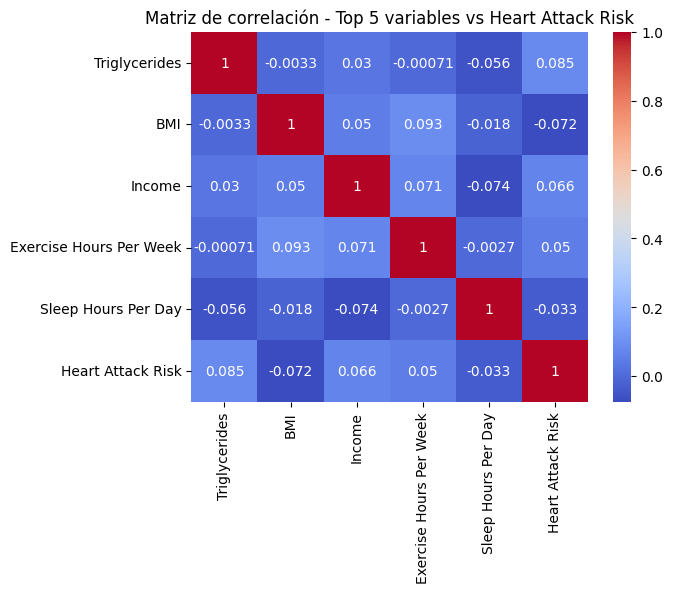

In [28]:
#Seleccionamos las variables del enunciado
variables_enunciado = [
    "Exercise Hours Per Week",
    "Income",
    "BMI",
    "Triglycerides",
    "Sleep Hours Per Day"
]

y_col = "Heart Attack Risk"

# Subconjunto de datos solo con las variables de interés
subset = XDB_country[variables_enunciado + [y_col]].dropna()

# Calculamos la matriz de correlaciones
corr_matrix = subset.corr()

# Serie con las correlaciones frente a la variable objetivo
corr_series = corr_matrix[y_col].drop(labels=[y_col])

# Ordenamos por magnitud (valor absoluto) y seleccionamos las 5 más importantes
top5_corr = corr_series.abs().sort_values(ascending=False).head(5)
selected_vars = top5_corr.index.tolist()

print("Top 5 variables más correlacionadas con Heart Attack Risk:")
for var in selected_vars:
    print(f" - {var}: correlación = {corr_series[var]:.4f}")

# Visualización con un heatmap
sns.heatmap(subset[selected_vars + [y_col]].corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de correlación - Top 5 variables vs Heart Attack Risk")
plt.show()

4. Creamos los dataset para evaluar los modelos de clasificación (Bayes) (Árbol de decisión) y hacer sus predicciones

In [29]:
XD = XDB_country[['Exercise Hours Per Week','Income','BMI','Triglycerides','Sleep Hours Per Day']]
yd = XDB_country["Heart Attack Risk"]

5. Miramos el porcentaje de personas con riesgo de ataque cardiaco

In [30]:
#Porcentaje de personas con riesgo de ataque cardiaco
from re import X
XDB_country["Heart Attack Risk"].value_counts(normalize=True)


,proportion
Heart Attack Risk,
0,0.622378
1,0.377622


#Bayes

6. Empleamos el modelo de Naive Bayes

In [31]:
#Implementamos el modelo de clasificación Naive-Bayes
mnb = GaussianNB()
mnb.fit(XD, yd)

GaussianNB()

7. Evaluamos estadisticamente el modelo de Bayes

In [32]:
# Configuramos cómo se mostrarán los resultados numéricos de NumPy:
# - suppress=True → evita notación científica (e.g., 1e-05)
# - precision=3 → limita los decimales mostrados a 3 cifras
np.set_printoptions(suppress=True, precision=3)

# Obtenemos la media (theta) de las variables por categoría del modelo Naive Bayes
# 'mnb.theta_' guarda la media estimada de cada variable en cada clase
u = mnb.theta_
print("La media de las variables es:\n", u)

print("")

# Obtenemos la cantidad de datos observados en cada categoría
# 'class_count_' guarda el número de muestras que corresponden a cada clase
ndat = mnb.class_count_
print("El número de datos por categoría es:\n", ndat)

# Obtenemos los nombres/etiquetas de las categorías (clases)
# 'classes_' indica cuáles son las clases que el modelo reconoce
cat = mnb.classes_
print("Las categorías son:\n", cat)

print("")

# Calculamos la desviación estándar de las variables por categoría
# 'mnb.var_' contiene la varianza, y le aplicamos raíz cuadrada para obtener la desviación estándar
sigma = np.sqrt(mnb.var_)
print("La desviación estándar de las variables es:\n", sigma)

print("")

# Calculamos los límites superiores (media + desviación estándar)
# Esto da una idea del rango superior esperado de cada variable
print("Los límites superiores de las variables son:\n", u + sigma)

print("")

# Calculamos los límites inferiores (media - desviación estándar)
# Esto da una idea del rango inferior esperado de cada variable
print("Los límites inferiores de las variables son:\n", u - sigma)


La media de las variables es:
 [[     9.651 152847.393     29.066    390.09       7.022]
 [    10.24  163714.821     28.136    430.957      6.889]]

El número de datos por categoría es:
 [267. 162.]
Las categorías son:
 [0 1]

La desviación estándar de las variables es:
 [[    6.202 79023.434     6.622   235.626     3.238]
 [    6.289 81835.996     6.945   228.722     3.154]]

Los límites superiores de las variables son:
 [[    15.853 231870.828     35.687    625.716     10.261]
 [    16.529 245550.817     35.081    659.679     10.043]]

Los límites inferiores de las variables son:
 [[    3.449 73823.959    22.444   154.464     3.784]
 [    3.952 81878.825    21.192   202.234     3.735]]


8. Evaluamos el desempeño del modelo

In [33]:
#Evaluación del desempeño del modelo
ydb = mnb.predict(XD)
print("Las predicciones son:\n", ydb)

#Matriz de confusión
cm = confusion_matrix(yd, ydb)
print("La matriz de confusión es:\n", cm)

Las predicciones son:
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 1 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
La matriz de confusión es:
 [[260   7]
 [158   4]]


9. Vemos las metricas de desempeño

In [34]:
# MÉTRICAS DE DESEMPEÑO DEL MODELO

# Total de datos en el conjunto de evaluación
TD = len(XD)

# -------------------------------
# Valores obtenidos de la Matriz de Confusión (cm)
# cm tiene la forma:
# [[VN, FP],
#  [FN, VP]]

VN = cm[0,0]  # Verdaderos Negativos: casos 0 correctamente predichos como 0
FP = cm[0,1]  # Falsos Positivos: casos 0 incorrectamente predichos como 1
FN = cm[1,0]  # Falsos Negativos: casos 1 incorrectamente predichos como 0
VP = cm[1,1]  # Verdaderos Positivos: casos 1 correctamente predichos como 1

# -------------------------------
# Exactitud (Accuracy): proporción total de aciertos
Ex = (VP + VN) / TD
print("Exactitud:", Ex)

# Tasa de error: proporción total de errores
Ter = (FP + FN) / TD
print("Tasa de error:", Ter)

# -------------------------------
# Sensibilidad (Recall para positivos):
# capacidad del modelo para detectar correctamente los positivos
Sen = VP / (VP + FN)
print("Sensibilidad:", Sen)

# Especificidad:
# capacidad del modelo para detectar correctamente los negativos
Esp = VN / (VN + FP)
print("Especificidad:", Esp)

# -------------------------------
# Precisión (Precision para positivos):
# proporción de predicciones positivas que realmente son correctas
Pre = VP / (FP + VP)
print("Precisión:", Pre)

# Precisión Negativa:
# proporción de predicciones negativas que realmente son correctas
Prn = VN / (VN + FN)
print("Precisión negativa:", Prn)


Exactitud: 0.6153846153846154
Tasa de error: 0.38461538461538464
Sensibilidad: 0.024691358024691357
Especificidad: 0.9737827715355806
Precisión: 0.36363636363636365
Precisión negativa: 0.6220095693779905


In [35]:
#Clasificación de persona en función de los datos personales
XI = [200, 6, 1, 230, 285768]
ydpi = mnb.predict([XI])

resultado = "Esta persona puede sufrir de ataque cardiaco" if ydpi[0] == 1 else "Esta persona sufrirá un ataque cardiaco"
print("La categoría de la persona es:", ydpi, "y", resultado)


La categoría de la persona es: [0] y Esta persona sufrirá un ataque cardiaco


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


#Árbol de decisión

10. Utilizamos el metodo de árbol de decisión, a continuación configuramos sus parametros y vemos su efectividad.

In [36]:
#Realizamos la configuración de los arboles de decisión. La profundidad la ponemos en 6, como suele hacerse por convención
mar = DecisionTreeClassifier(criterion = "gini", max_depth = 6)
mar.fit(XD, yd)

# Visualización del árbol (se guarda como PNG)
dot_data = export_graphviz(mar, feature_names=XD.columns)

graph = graph_from_dot_data(dot_data)
graph.write_png('DecisionTree_Parcial.png')

True

In [37]:
# Usamos el modelo 'mar' previamente entrenado para hacer predicciones
# sobre el conjunto de datos de entrada 'XD'
# 'ydp' contendrá las etiquetas predichas por el modelo
ydp = mar.predict(XD)

# Calculamos la matriz de confusión comparando:
# - 'yd' → las etiquetas reales (valores verdaderos de la variable objetivo)
# - 'ydp' → las etiquetas predichas por el modelo
# La matriz de confusión mostrará la distribución de aciertos y errores
cm = confusion_matrix(yd, ydp)

# Imprimimos un mensaje en pantalla para identificar el resultado
print("Matriz de Confusión:")

# Mostramos la matriz de confusión calculada
print(cm)


Matriz de Confusión:
[[245  22]
 [ 71  91]]


In [38]:
# MÉTRICAS - ÁRBOL DE DECISIÓN


# Extraemos los valores de la matriz de confusión (cm)
# cm tiene la forma:
# [[VN, FP],
#  [FN, VP]]

VN = cm[0,0]   # Verdaderos Negativos: reales 0 predichos como 0
FP = cm[0,1]   # Falsos Positivos: reales 0 predichos como 1
FN = cm[1,0]   # Falsos Negativos: reales 1 predichos como 0
VP = cm[1,1]   # Verdaderos Positivos: reales 1 predichos como 1

# Total de datos evaluados
TD = len(XD)

# -------------------------------
# Exactitud (Accuracy): porcentaje de aciertos globales
Ex  = (VN + VP) / TD

# Tasa de Error: porcentaje de clasificaciones incorrectas
Ter = (FP + FN) / TD

# Sensibilidad (Recall para positivos):
# capacidad del modelo para detectar correctamente los casos positivos (clase 1 = Ataque)
Sen = VP / (VP + FN)

# Especificidad (Recall para negativos):
# capacidad del modelo para detectar correctamente los casos negativos (clase 0 = No Ataque)
Esp = VN / (VN + FP)

# Precisión positiva (PPV):
# proporción de predicciones positivas que son correctas
Pre = VP / (VP + FP)

# Precisión negativa (NPV):
# proporción de predicciones negativas que son correctas
Prn = VN / (VN + FN)

# -------------------------------
# Mostramos resultados
print("\nMétricas manuales del modelo Árbol de Decisión")
print("")
print(f"Exactitud (Accuracy): {Ex}")
print(f"Tasa de Error: {Ter}")
print(f"Sensibilidad (Recall clase 1 - Ataque): {Sen}")
print(f"Especificidad (Recall clase 0 - No Ataque): {Esp}")
print(f"Precisión Positiva (PPV): {Pre}")
print(f"Precisión Negativa (NPV): {Prn}")



Métricas manuales del modelo Árbol de Decisión

Exactitud (Accuracy): 0.7832167832167832
Tasa de Error: 0.21678321678321677
Sensibilidad (Recall clase 1 - Ataque): 0.5617283950617284
Especificidad (Recall clase 0 - No Ataque): 0.9176029962546817
Precisión Positiva (PPV): 0.8053097345132744
Precisión Negativa (NPV): 0.7753164556962026


In [61]:
# Acceder al árbol entrenado
tree = mar.tree_
feature_names = XD.columns
target_names = ["No Heart Attack", "Heart Attack"]

def find_pure_node_rules(node_id, rule_string, pure_nodes):
    """Busca recursivamente las reglas que llevan a nodos puros (gini = 0)."""
    # Si el nodo es hoja
    if tree.children_left[node_id] == tree.children_right[node_id]:
        # Revisar si es puro (gini ≈ 0 con tolerancia)
        if tree.impurity[node_id] <= 1e-9:
            value = tree.value[node_id][0]
            # Convertir los valores a enteros para que no muestre decimales
            value_int = value.astype(int)
            predicted_class = target_names[np.argmax(value)]
            pure_nodes.append((rule_string, predicted_class, value_int))
        return

    # Obtener la condición del nodo
    feature = feature_names[tree.feature[node_id]]
    threshold = tree.threshold[node_id]

    # Llamar recursivamente para hijos
    left_child_id = tree.children_left[node_id]
    right_child_id = tree.children_right[node_id]

    find_pure_node_rules(left_child_id, f"{rule_string} and {feature} <= {threshold:.2f}", pure_nodes)
    find_pure_node_rules(right_child_id, f"{rule_string} and {feature} > {threshold:.2f}", pure_nodes)

# Ejecutar desde la raíz
pure_nodes = []
find_pure_node_rules(0, "Root", pure_nodes)

# Mostrar resultados en tabla
df_rules = pd.DataFrame([
    {
        "Regla": rule.replace("Root and ", ""),
        "Predicción": predicted_class,
        "Value": value.tolist()
    }
    for rule, predicted_class, value in pure_nodes
])

print(df_rules)


                                                Regla       Predicción   Value
0      BMI <= 20.27 and BMI <= 19.20 and BMI <= 18.33     Heart Attack  [0, 1]
1   BMI <= 20.27 and BMI <= 19.20 and BMI > 18.33 ...     Heart Attack  [0, 1]
2   BMI <= 20.27 and BMI <= 19.20 and BMI > 18.33 ...  No Heart Attack  [1, 0]
3   BMI <= 20.27 and BMI <= 19.20 and BMI > 18.33 ...     Heart Attack  [0, 1]
4   BMI <= 20.27 and BMI > 19.20 and Triglycerides...     Heart Attack  [0, 1]
5   BMI <= 20.27 and BMI > 19.20 and Triglycerides...  No Heart Attack  [1, 0]
6   BMI <= 20.27 and BMI > 19.20 and Triglycerides...     Heart Attack  [0, 1]
7   BMI <= 20.27 and BMI > 19.20 and Triglycerides...     Heart Attack  [0, 1]
8   BMI <= 20.27 and BMI > 19.20 and Triglycerides...     Heart Attack  [0, 1]
9   BMI <= 20.27 and BMI > 19.20 and Triglycerides...  No Heart Attack  [1, 0]
10  BMI > 20.27 and Triglycerides <= 492.00 and In...     Heart Attack  [0, 1]
11  BMI > 20.27 and Triglycerides <= 492.00 and In..

El modelo de Árbol de Decisión presenta una exactitud global del 78%, mostrando un buen desempeño en la identificación de personas sin riesgo de ataque cardíaco gracias a su alta especificidad (92%). Sin embargo, su sensibilidad es relativamente baja (56%), lo que implica que deja escapar casi la mitad de los casos reales de ataque. Esto significa que, aunque el modelo es confiable para descartar casos sin riesgo, no resulta suficientemente robusto para detectar con precisión a quienes realmente presentan peligro, lo cual representa una limitación importante en un contexto de salud.

#K-MEANS


11. Separamos los datos en grupos usando Clusterización con K-Means.

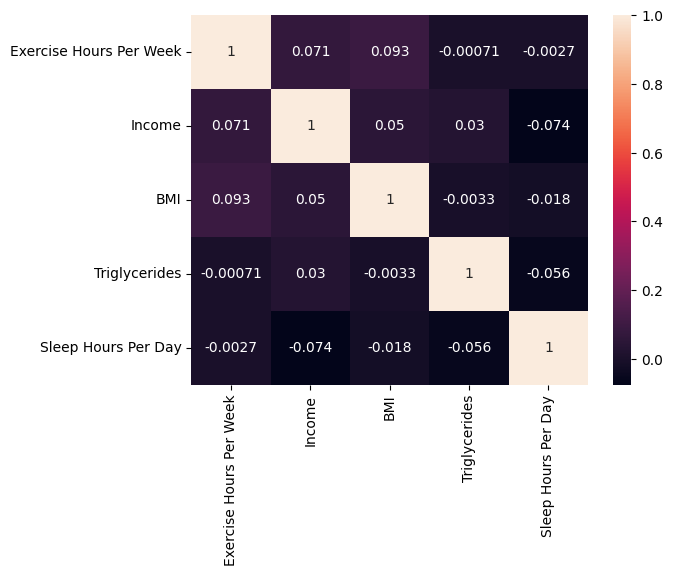

In [39]:
# Calculamos la matriz de correlación de todas las variables numéricas
# excepto 'Country' (porque es categórica)
corr = XDB_country.drop(columns=['Country']).corr()

# Dibujamos un heatmap (mapa de calor) con seaborn,
# pero solo para un subconjunto de variables seleccionadas:
# 'Exercise Hours Per Week', 'Income', 'BMI', 'Triglycerides', 'Sleep Hours Per Day'
sns.heatmap(
    XDB_country[['Exercise Hours Per Week','Income','BMI','Triglycerides','Sleep Hours Per Day']].corr(),
    annot=True # Muestra los valores de correlación dentro de cada celda
)

# Mostramos el gráfico
plt.show()


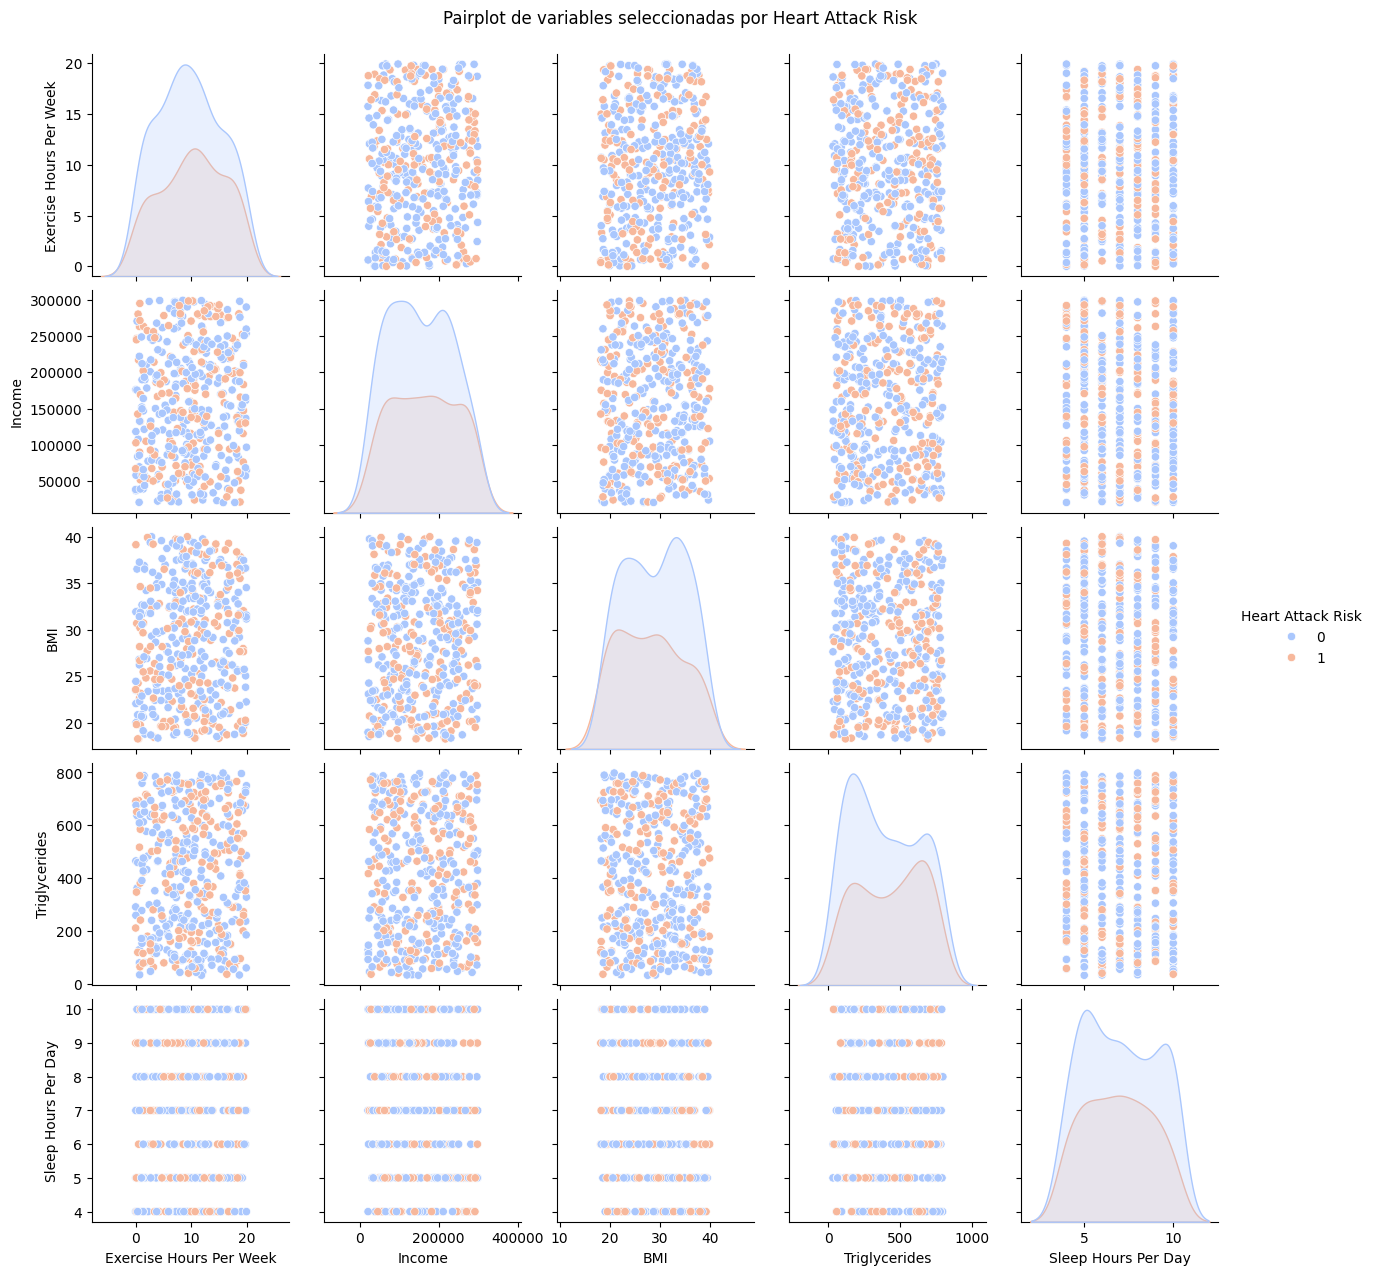

In [40]:
# Pairplot de variables seleccionadas con color por la variable objetivo
sns.pairplot(
    XDB_country,
    hue='Heart Attack Risk',   # Colorear por la variable de riesgo
    vars=['Exercise Hours Per Week','Income','BMI','Triglycerides','Sleep Hours Per Day'],
    diag_kind='kde',           # Distribuciones suavizadas en la diagonal
    palette='coolwarm'         # Paleta de colores personalizada
)

plt.suptitle("Pairplot de variables seleccionadas por Heart Attack Risk", y=1.02)
plt.show()

Este gráfico muestra que ninguna variable por sí sola separa perfectamente el riesgo de ataque cardíaco, pero ciertas combinaciones (ejercicio, BMI y triglicéridos) empiezan a mostrar ligeras diferencias entre los grupos.

In [41]:
# Definir número de clusters
k = 5
mkm = KMeans(n_clusters=k, init='random', random_state=42)

# Entrenamiento del modelo
mkm.fit(XD)

# Resultados
centroids = pd.DataFrame(
    mkm.cluster_centers_,
    columns=['Exercise Hours Per Week','Income','BMI','Triglycerides','Sleep Hours Per Day']
)
labels = mkm.labels_

print("Centroides de los clusters:")
print(centroids)

# Agregar etiquetas de cluster al dataset original
XDB_country['Cluster'] = labels


Centroides de los clusters:
   Exercise Hours Per Week         Income        BMI  Triglycerides  \
0                10.544860  144999.405063  28.682191     401.544304   
1                 9.124484   97851.594595  28.203750     384.270270   
2                10.404441  203773.387755  29.078943     429.193878   
3                 9.964734  268841.230769  28.964479     399.120879   
4                 9.208167   48295.862069  28.507622     407.241379   

   Sleep Hours Per Day  
0             7.177215  
1             7.067568  
2             7.030612  
3             6.582418  
4             7.045977  


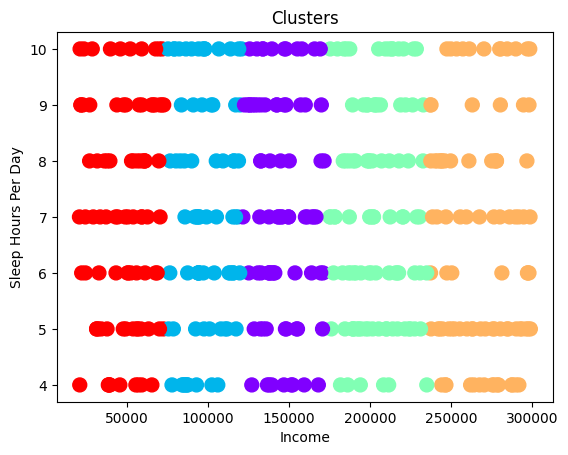

In [42]:
# Visualizamos los clusters

plt.figure()
plt.scatter(XD['Income'], XD['Sleep Hours Per Day'], c=labels, s=100, cmap='rainbow')
plt.xlabel('Income')
plt.ylabel('Sleep Hours Per Day')
plt.title('Clusters')
plt.show()


In [43]:
import pandas as pd

# Comparar clusters vs Heart Attack Risk
ct = pd.crosstab(XDB_country['Cluster'], XDB_country['Heart Attack Risk'])
print(ct)


Heart Attack Risk   0   1
Cluster                  
0                  47  32
1                  52  22
2                  64  34
3                  50  41
4                  54  33


El clustering con estas 5 variables logra cierto agrupamiento de patrones, pero no separa claramente a las personas con riesgo de las que no lo tienen. Esto es normal porque K-Means no sabe nada del Heart Attack Risk y solo agrupa por similitud matemática en los valores.

In [44]:
# Número de datos por Cluster
ND = np.bincount(labels)  # Cuántos datos hay por cluster
print("Numero de datos por cluster:", ND)

# Añadir columna con el cluster asignado
XDB_country["Cluster"] = labels


Numero de datos por cluster: [79 74 98 91 87]


In [45]:
# Medias de cada cluster para las variables seleccionadas
cluster_means = XDB.groupby(XDB_country["Cluster"])[
    ['Exercise Hours Per Week','Income','BMI','Triglycerides','Sleep Hours Per Day']
].mean()

print("Medias de cada variable en los clusters:")
display(cluster_means)


Medias de cada variable en los clusters:


,Exercise Hours Per Week,Income,BMI,Triglycerides,Sleep Hours Per Day
Cluster,,,,,
0.0,10.544860,144999.405063,28.682191,401.544304,7.177215
1.0,9.124484,97851.594595,28.203750,384.270270,7.067568
2.0,10.404441,203773.387755,29.078943,429.193878,7.030612
3.0,9.964734,268841.230769,28.964479,399.120879,6.582418
4.0,9.208167,48295.862069,28.507622,407.241379,7.045977


In [46]:
# Análisis de clusters
Ataque = XDB.groupby(XDB_country["Cluster"])[['Heart Attack Risk']].value_counts()
NAtaque = XDB.groupby(XDB_country["Cluster"]).agg({"Heart Attack Risk": lambda x: (x==1).sum()})
NNoAtaque = XDB.groupby(XDB_country["Cluster"]).agg({'Heart Attack Risk': lambda x: (x==0).sum()})

NAtaque['Porcentaje'] = NAtaque['Heart Attack Risk'] / ND * 100
print("")
print("Porcentaje de personas con riesgo de sufrir ataque cardiago por cluster:")
print(NAtaque)
print("")

print("Porcentaje de personas sin riesgo de sufrir ataque cardiago por cluster:")
NNoAtaque['Porcentaje'] = NNoAtaque['Heart Attack Risk'] / ND * 100
print(NNoAtaque)



Porcentaje de personas con riesgo de sufrir ataque cardiago por cluster:
         Heart Attack Risk  Porcentaje
Cluster                               
0.0                     32   40.506329
1.0                     22   29.729730
2.0                     34   34.693878
3.0                     41   45.054945
4.0                     33   37.931034

Porcentaje de personas sin riesgo de sufrir ataque cardiago por cluster:
         Heart Attack Risk  Porcentaje
Cluster                               
0.0                     47   59.493671
1.0                     52   70.270270
2.0                     64   65.306122
3.0                     50   54.945055
4.0                     54   62.068966


In [47]:
# Determinar la predicción del cluster (basado en si el porcentaje de riesgo es mayor que el de no riesgo)
ydp = np.zeros(len(XDB_country["Cluster"]))
for i in range(len(XDB_country["Cluster"])):
    cluster_id = XDB_country["Cluster"].iloc[i]
    # Acceder a los DataFrames usando .loc con el ID del cluster como flotante
    if NAtaque.loc[float(cluster_id), 'Porcentaje'] > NNoAtaque.loc[float(cluster_id), 'Porcentaje']:
        ydp[i] = 1
    else:
        ydp[i] = 0

print("La predicción del cluster es:\n", ydp)



La predicción del cluster es:
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0

In [48]:
# Calcular la matriz de confusión comparando el riesgo real con la predicción basada en el cluster
cm = confusion_matrix(XDB_country["Heart Attack Risk"], ydp)
print("Matriz de confusión Clustering Kmeans:\n", cm)


Matriz de confusión Clustering Kmeans:
 [[267   0]
 [162   0]]


In [49]:
# Extraemos los valores de la matriz de confusión
VN = cm[0,0]   # Verdaderos Negativos: sin riesgo correctamente clasificados
FP = cm[0,1]   # Falsos Positivos: sin riesgo clasificados como riesgo
FN = cm[1,0]   # Falsos Negativos: con riesgo clasificados como sin riesgo
VP = cm[1,1]   # Verdaderos Positivos: con riesgo correctamente clasificados

# Total de datos (suma de todos los elementos de la matriz)
TD = len(XDB_country["Cluster"])

# Exactitud (Accuracy): proporción de predicciones correctas (VP + VN) sobre el total
Exactitud = (VP + VN) / TD
print("la exactitud es:", Exactitud)

# Tasa de error: proporción de clasificaciones incorrectas (FP + FN) sobre el total
Ter = (FN + FP) / TD
print("la tasa de error es:", Ter)

# Sensibilidad (Recall / True Positive Rate): capacidad de detectar a los que sí tienen riesgo
Sen = VP / (VP + FN) if (VP + FN) != 0 else 0
print("la sensibilidad es:", Sen)

# Especificidad (True Negative Rate): capacidad de detectar a los que no tienen riesgo
Esp = VN / (VN + FP) if (VN + FP) != 0 else 0
print("la especificidad es:", Esp)

# Precisión (Precision / Positive Predictive Value): de los predichos como riesgo, cuántos realmente lo son
Pr = VP / (FP + VP) if (FP + VP) != 0 else 0
print("la precision es:", Pr)

# Valor predictivo negativo (Negative Predictive Value): de los predichos como sin riesgo, cuántos realmente lo son
prn = VN / (VN + FN) if (VN + FN) != 0 else 0
print("la prediccion negativa es:", prn)


la exactitud es: 0.6223776223776224
la tasa de error es: 0.3776223776223776
la sensibilidad es: 0.0
la especificidad es: 1.0
la precision es: 0
la prediccion negativa es: 0.6223776223776224


In [50]:
# Analizar la posibilidad de sufrir un Ataque Cardiaco que tienen las personas de la hoja "Pronóstico"

# Ruta del archivo Excel
nxl = '/content/3. heart_attack_pronostico_int.xlsx'

# Cargar la hoja 1 del archivo
XDBH1 = pd.read_excel(nxl, sheet_name=1)

# Seleccionar variables de interés
XDBH1 = XDBH1[['Exercise Hours Per Week','Income','BMI','Triglycerides','Sleep Hours Per Day']]
XDBH1 = XDBH1.dropna()

# Predicción con K-Means (asignar cluster)
clusters_pred = mkm.predict(XDBH1.values)

# Predicción de probabilidades con Naive Bayes
proba = mnb.predict_proba(XDBH1)

# Crear un DataFrame con los resultados
resultados = pd.DataFrame({
    "Persona": range(1, len(XDBH1) + 1),
    "Cluster Asignado": clusters_pred,
    "Prob_No_Riesgo": proba[:,0],
    "Prob_Riesgo": proba[:,1]
})

# Mostrar resultados organizados
print("\n Resultados del Análisis de Riesgo de Ataque Cardiaco\n")
print(resultados.to_string(index=False))



 Resultados del Análisis de Riesgo de Ataque Cardiaco

 Persona  Cluster Asignado  Prob_No_Riesgo  Prob_Riesgo
       1                 4        0.713815     0.286185
       2                 2        0.610965     0.389035
       3                 2        0.678322     0.321678


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


Cluster 1 = grupo más sano.

Cluster 3 = grupo más vulnerable.

Los demás clusters están en una situación mixta (entre 35% y 40% de riesgo).

#**Análisis de resultados**



A continuación haremos un análisis exhaustivo para tratar de entender la correlación y las variables seleccionadas:

- Triglycerides (correlación = 0.0847, positiva):
→ A mayor nivel de triglicéridos, mayor riesgo de sufrir un ataque cardiaco.
Esto tiene sentido clínico, porque los triglicéridos altos están vinculados a problemas cardiovasculares.

- BMI (Índice de Masa Corporal) (correlación = -0.0719, negativa):
→ Sorprendentemente, la correlación es negativa en este dataset. Es decir, un mayor BMI se asocia con menor riesgo de ataque.
Esto podría deberse a ruido en los datos, a la composición de la muestra, o a la interacción con otras variables (ejemplo: personas con más masa corporal pero menor edad). No implica causalidad.

- Income (Ingresos) (correlación = 0.0656, positiva):
→ Personas con mayores ingresos muestran una ligera asociación con mayor riesgo.
Esto también podría estar reflejando factores indirectos: estilo de vida sedentario, alimentación, estrés laboral.

- Exercise Hours per Week (Horas de ejercicio por semana) (correlación = 0.0501, positiva):
→ La correlación positiva es contraintuitiva, porque normalmente más ejercicio reduce riesgo.
Puede deberse a que las personas en riesgo ya diagnosticadas intentan ejercitarse más, lo que introduce un sesgo en la base de datos.

- Sleep Hours per Day (Horas de sueño por día) (correlación = -0.0330, negativa):
→ Dormir menos horas está ligeramente asociado con mayor riesgo, algo esperado en la literatura médica.

&nbsp;

&nbsp;

El número de personas que tienen más riesgo de sufrir un ataque cardiaco en Colombia son 162 personas, la población sin riesgo son 267 personas, para un total de 429 personas.   

Respecto a Bayes, tenemos que el modelo alcanzó una exactitud de aproximadamente 61.5%, lo que indica un desempeño moderado en la clasificación general. Sin embargo, la tasa de error es relativamente alta, cercana al 38.4%, lo que refleja una proporción considerable de predicciones incorrectas. La sensibilidad es extremadamente baja, con apenas un 2.4%, lo que significa que el modelo prácticamente no logra identificar a las personas que realmente tienen riesgo de sufrir un ataque cardiaco. En contraste, la especificidad es elevada, con un 97.3%, mostrando que sí clasifica adecuadamente a quienes no tienen riesgo. La precisión general se ubica en 36.3%, evidenciando que una parte significativa de los casos predichos como positivos son falsos. Por otro lado, la precisión negativa es de 62.2%, lo que sugiere que, aunque el modelo tiene un buen rendimiento en la detección de personas sin riesgo, falla críticamente en identificar a quienes sí lo presentan, comprometiendo su utilidad práctica en un contexto de salud.

&nbsp;

&nbsp;

El árbol de decisión mostró un desempeño superior al modelo de Naive Bayes, alcanzando una exactitud de 78.3%, lo que indica que logra clasificar correctamente a una buena proporción de los casos. La tasa de error fue del 21.6%, considerablemente menor que la observada con Bayes. En cuanto a la sensibilidad, el modelo identificó correctamente al 56.1% de los pacientes con riesgo de ataque cardiaco, un valor moderado que muestra cierta capacidad para detectar positivos, aunque aún existen falsos negativos relevantes. La especificidad fue alta, del 91.7%, evidenciando que el árbol clasifica con gran eficacia a quienes no presentan riesgo. En términos de precisión, el valor positivo predictivo alcanzó 80.5%, lo que significa que la gran mayoría de los casos predichos como positivos efectivamente lo eran. La precisión negativa fue de 77.5%, lo cual respalda la confiabilidad del modelo en las predicciones de no riesgo.

En cuanto a las reglas extraídas, el modelo mostró que las variables más influyentes en la clasificación fueron principalmente el Índice de Masa Corporal (BMI) y los Triglicéridos, en algunos casos acompañados por el ingreso económico y las horas de ejercicio o sueño. Por ejemplo, se observa que valores bajos de BMI combinados con ciertos rangos de triglicéridos llevan a predicciones de riesgo, mientras que niveles más altos de BMI junto con triglicéridos bajos tienden a asociarse con ausencia de riesgo. Este hallazgo coincide con la literatura médica, ya que el BMI y los triglicéridos son factores de riesgo conocidos para problemas cardiovasculares.

En conclusión, el árbol de decisión ofrece un balance entre detección de riesgo y confiabilidad en las predicciones, posicionándose como una herramienta más adecuada que Naive Bayes para el análisis de este conjunto de datos. No obstante, la sensibilidad aún es limitada, lo que sugiere la necesidad de ajustar parámetros o complementar con otros métodos para reducir los falsos negativos y mejorar la identificación de pacientes en riesgo real.


&nbsp;


&nbsp;

El modelo de K-means aplicado a los datos permitió identificar cinco grupos diferenciados de individuos según variables como el número de horas de ejercicio por semana, ingreso, índice de masa corporal (BMI), niveles de triglicéridos y horas de sueño. Los centroides mostraron perfiles relativamente cercanos entre sí, aunque con diferencias importantes en el ingreso y el patrón de sueño, destacando un cluster con ingresos muy bajos y otro con ingresos notablemente altos.

En cuanto al riesgo de ataque cardiaco, los porcentajes dentro de los clusters oscilaron entre un 29.7% y un 45%, lo que sugiere que algunos grupos presentan mayor concentración de personas en riesgo. Por ejemplo, el cluster 3 se caracteriza por ingresos muy altos y una media de horas de sueño más baja (6.58 horas) y fue el que presentó la proporción más alta de riesgo (45%), mientras que el cluster 1, con ingresos más bajos y triglicéridos relativamente bajos, mostró la menor proporción de riesgo (29.7%). Esto refleja que tanto el ingreso como los hábitos de sueño podrían tener un impacto indirecto en el riesgo percibido.

Sin embargo, al evaluar el rendimiento del clustering como clasificador, los resultados fueron limitados. La exactitud alcanzó 62.2%, con una tasa de error de 37.7%. La especificidad fue perfecta (100%), es decir, el modelo clasificó muy bien a quienes no presentan riesgo, pero la sensibilidad fue nula (0.0), lo que significa que no logró identificar correctamente a los individuos en riesgo. De igual manera, la precisión fue 0, lo que refuerza que el modelo no fue capaz de predecir ataques cardiacos de forma efectiva.

En los resultados del análisis de riesgo de ataque cardiaco por persona, se observa que, por ejemplo, una persona asignada al cluster 4 presenta una probabilidad de 71.38% de no estar en riesgo frente a un 28.62% de estarlo. Otra persona perteneciente al cluster 2 muestra una probabilidad de 61.09% de no riesgo y 38.90% de riesgo, mientras que otra en el mismo cluster 2 presenta un 67.83% de probabilidad de no riesgo y un 32.17% de probabilidad de riesgo. Estos valores ilustran cómo, a pesar de que el modelo no es un buen predictor individual, sí permite observar matices en los niveles de riesgo relativo dentro de los diferentes clusters.

Aunque el K-means permitió encontrar grupos con características diferenciadas que pueden dar pistas sobre perfiles de riesgo, su utilidad como modelo predictivo fue muy limitada, ya que tiende a concentrar las predicciones en la clase negativa (no riesgo). Su valor principal en este contexto radica en el descubrimiento de patrones y perfiles de pacientes, más que en la predicción directa del riesgo.

&nbsp;

&nbsp;


Al comparar los tres enfoques aplicados —Naive Bayes, Árbol de Decisión y K-means— se observa un panorama claro sobre sus fortalezas y limitaciones en el análisis del riesgo de ataque cardiaco.

El modelo de Naive Bayes mostró un desempeño bastante débil: si bien alcanzó una exactitud cercana al 61.5%, su sensibilidad fue muy baja (2.4%), lo que significa que casi no identificó a los pacientes en riesgo. Esto se traduce en un alto número de falsos negativos, lo cual es problemático en un escenario de salud donde la prioridad es detectar a quienes podrían sufrir un evento cardiaco. Su principal fortaleza fue la especificidad (97.3%), pero a costa de sacrificar la capacidad de detección de positivos.

Por otro lado, el Árbol de Decisión fue el modelo más balanceado. Alcanzó una exactitud del 78.3%, con una sensibilidad de 56.1% y una especificidad de 91.7%. Esto implica que logró identificar a más de la mitad de los pacientes en riesgo sin perder demasiada precisión en la clasificación de los sanos. Además, la precisión positiva fue alta (80.5%), lo que significa que la mayoría de las veces que predijo un ataque cardiaco, la predicción fue correcta. A través de sus reglas de decisión, también permitió interpretar los factores más influyentes, principalmente el índice de masa corporal (BMI) y los triglicéridos, lo cual es consistente con la evidencia médica.

Finalmente, el K-means cumplió un rol diferente: más que predecir, permitió segmentar a los individuos en cinco grupos con características similares en hábitos, ingresos y niveles de triglicéridos. Los clusters revelaron patrones interesantes, como la asociación entre menores horas de sueño e ingresos altos con un mayor porcentaje de riesgo. Sin embargo, como clasificador fue muy limitado: aunque tuvo una exactitud del 62.2% y especificidad perfecta (100%), su sensibilidad fue nula, es decir, no logró identificar a ningún paciente en riesgo. Su aporte es más exploratorio y descriptivo que predictivo.

En conclusión, el Árbol de Decisión se posiciona como el modelo más adecuado para este problema, al ofrecer un equilibrio entre detección de riesgo y precisión, además de generar reglas interpretables. Naive Bayes, aunque simple, no resulta confiable en este caso por su incapacidad de detectar positivos. K-means, en cambio, es valioso como herramienta de segmentación para identificar perfiles de pacientes, pero no como predictor directo del riesgo. Una estrategia óptima podría ser usar el Árbol de Decisión como modelo principal de predicción, complementado con K-means para analizar patrones poblacionales y posibles perfiles de riesgo diferenciados.